In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf



In [20]:
# load data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(x_train.shape)

(60000, 28, 28)


In [21]:
from sklearn.utils import shuffle

# preprocess
# shuffle
x_train, y_train = shuffle(x_train, y_train)
# select a small subset of data
x_train = x_train[:10000]
# scale from 0 to 1
x_train = x_train / 255
# scale x_train from -1 to 1
x_train = (x_train.reshape(-1, 28, 28, 1) * 2.0) - 1.0
# print min max
x_train.min(), x_train.max()
# change dtype
x_train = tf.cast(x_train, dtype=tf.float32)
#x_train = x_train.astype(np.float32)

In [22]:
coding_size = 200

# generator
generator = tf.keras.models.Sequential([
    tf.keras.layers.Dense(7*7*128, input_shape=([coding_size])),
    tf.keras.layers.Reshape([7,7, 128]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2DTranspose(32,
                                    kernel_size=5,
                                    strides=2,
                                    padding='same',
                                    activation='selu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2DTranspose(1,
                                    kernel_size=5,
                                    strides=2,
                                    padding='same',
                                    activation='tanh')
])

a = tf.random.normal(shape=[30, coding_size])
b = generator(a)
b.shape

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


TensorShape([30, 28, 28, 1])

In [23]:
# discriminator
discriminator = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(64,
                           kernel_size=5,
                           strides=2,
                           padding='same',
                           activation=tf.keras.layers.LeakyReLU(0.2),
                           input_shape=[28, 28, 1]),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Conv2D(128,
                           kernel_size=5,
                           strides=2,
                           padding='same',
                           activation=tf.keras.layers.LeakyReLU(0.2)),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
# gan
gan = tf.keras.models.Sequential([generator, discriminator])


In [25]:
# compile discriminator
discriminator.compile(loss='binary_crossentropy', optimizer='adam')

In [26]:
# switch of discriminator training
discriminator.trainable = False

# comile gan
gan.compile(loss='binary_crossentropy', optimizer='adam')

In [27]:
# make dataset
batch_size = 256
dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(1000)
dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(1)


In [28]:
# gan training function
def train_gan(gan, dataset, batch_size, coding_size, n_epochs=50):
  generator, discriminator = gan.layers
  for epoch in range(n_epochs):
    print(f'\n {epoch=}')
    for x_batch in dataset:
      print('. ', end='')
      # phase 1 - Train discriminator
      noise = tf.random.normal(shape=[batch_size, coding_size]) # generate noise
      fake_images = generator(noise) # generate fake images
      x_fake_and_real = tf.concat([fake_images, x_batch], axis=0) # concat with real images
      y1 = tf.constant([[0.]] * batch_size + [[1.]] * batch_size) # create fake (0.) and real (1.) labels
      discriminator.trainable = True
      discriminator.train_on_batch(x_fake_and_real, y1)

      # phase 2 - train generator by training gan
      noise = tf.random.normal(shape=[batch_size, coding_size]) # generate noise
      y2 = tf.constant([[1.]] * batch_size)
      discriminator.trainable = False
      gan.train_on_batch(noise, y2)




# train gan by calling the function
train_gan(gan, dataset, batch_size, coding_size, n_epochs=50)



 epoch=0
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
 epoch=1
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
 epoch=2
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
 epoch=3
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
 epoch=4
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
 epoch=5
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
 epoch=6
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
 epoch=7
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
 epoch=8
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
 epoch=9
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
 epoch=10
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
 epoch=11
. . . . . . . . . . 

In [29]:
# generate
noise = tf.random.normal(shape=[3, coding_size])
gen_images = generator(noise)


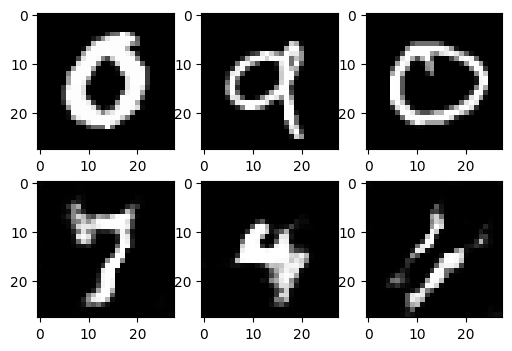

In [30]:
fig, [ax1, ax2] = plt.subplots(2,3, figsize=(6, 4))

for i in range(3):
  ax1[i].imshow(x_train[i], cmap="gray")
  ax2[i].imshow(gen_images[i], cmap='gray')

plt.show()